In [1]:
!pip install shap


[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: pip3 install --upgrade pip



--- LA 2028 PREDICTIONS (COMPLETE MODEL) ---
iso_code_mapped  Predicted_Total_Medals  Predicted_Medal_Share_Pct
            USA                   118.0                      10.12
            CHN                    93.7                       8.04
            RUS                    70.6                       6.06
            FRA                    63.9                       5.48
            GBR                    63.6                       5.45
            AUS                    51.3                       4.40
            JPN                    43.4                       3.72
            DEU                    39.6                       3.40
            ITA                    38.9                       3.34
            NLD                    35.1                       3.01
            KOR                    31.4                       2.69
            CAN                    29.4                       2.53
            BRA                    24.0                       2.06
            ESP 

NameError: name 'features' is not defined

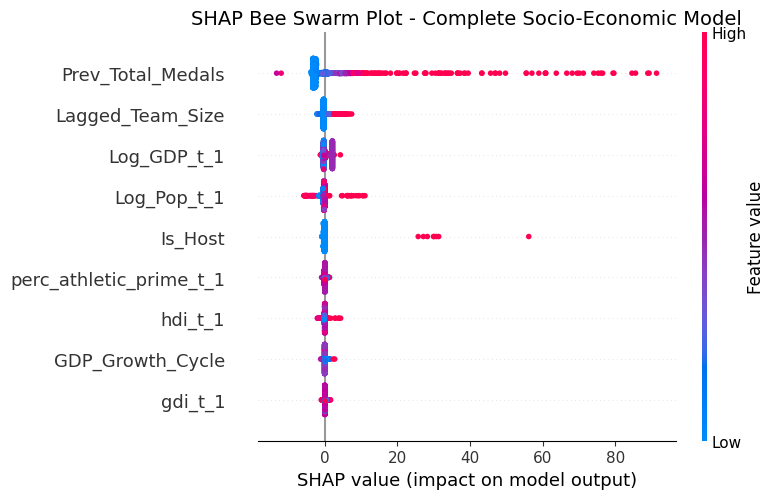

In [2]:
#CORRECT MODEL
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
import shap
from sklearn.inspection import permutation_importance
import matplotlib.pyplot as plt


df = pd.read_csv('dataset_thesis_new_hdi_v8.csv')

#  2024 Team Sizes
team_2024_data = {
    'USA': 592, 'FRA': 573, 'AUS': 460, 'GBR': 327, 'CHN': 388, 'DEU': 428, 'JPN': 403,
    'ITA': 371, 'ESP': 383, 'CAN': 315, 'NLD': 258, 'BRA': 277, 'KOR': 141, 'NZL': 195,
    'HUN': 170, 'ZAF': 138, 'MEX': 107, 'UKR': 140, 'CUB': 61, 'POL': 210, 'CHE': 127,
    'SWE': 117, 'BEL': 165, 'IRL': 133, 'ARG': 136, 'UZB': 86, 'IRN': 40, 'KAZ': 79,
    'KEN': 72, 'JAM': 58, 'ETH': 34, 'NOR': 107, 'DNK': 124, 
    'RUS': 335, 'BLR': 101  
}
for iso, size in team_2024_data.items():
    df.loc[(df['iso_code_mapped'] == iso) & (df['year'] == 2024), 'Team_Size'] = size
    
df = df.sort_values(['iso_code_mapped', 'year'])

df['Team_Size'] = df.groupby('iso_code_mapped')['Team_Size'].ffill()

# Russia/Belarus 2024 Medal Override
df.loc[(df['iso_code_mapped'] == 'RUS') & (df['year'] == 2024), 'Total'] = 71
df.loc[(df['iso_code_mapped'] == 'BLR') & (df['year'] == 2024), 'Total'] = 7

# Create Empty 2028 Rows
countries = df['iso_code_mapped'].unique()
df_2028 = pd.DataFrame({'iso_code_mapped': countries, 'year': 2028})
df = pd.concat([df, df_2028], ignore_index=True)
df = df.sort_values(['iso_code_mapped', 'year']).reset_index(drop=True)

#  LOCF for Structural Variables (Fills 2024 gaps and 2028 rows)
for col in ['hdi', 'gdi', 'population', 'GDP_merged', 'perc_athletic_prime']:
    df[col] = df.groupby('iso_code_mapped')[col].ffill()

#  Lags (t-1 and t-4)
for col in ['GDP_merged', 'population', 'hdi', 'gdi', 'perc_athletic_prime']:
    df[f'{col}_t_1'] = df.groupby('iso_code_mapped')[col].shift(1)

df['GDP_t_4'] = df.groupby('iso_code_mapped')['GDP_merged'].shift(4)
df['GDP_Growth_Cycle'] = ((df['GDP_merged_t_1'] - df['GDP_t_4']) / df['GDP_t_4']) * 100

olympic_years = [1996, 2000, 2004, 2008, 2012, 2016, 2021, 2024, 2028]
oly = df[df['year'].isin(olympic_years)].copy()
oly = oly.sort_values(['iso_code_mapped', 'year'])

oly['Lagged_Team_Size'] = oly.groupby('iso_code_mapped')['Team_Size'].shift(1)
oly['Prev_Total_Medals'] = oly.groupby('iso_code_mapped')['Total'].shift(1)

#  Prep Features
oly['Log_GDP_t_1'] = np.log10(oly['GDP_merged_t_1'])
oly['Log_Pop_t_1'] = np.log10(oly['population_t_1'])
oly['Is_Host'] = np.where((oly['iso_code_mapped'] == 'USA') & (oly['year'] == 2028), 1, oly['Is_Host'])

final_features = [
    'Log_GDP_t_1', 'Log_Pop_t_1', 'GDP_Growth_Cycle', 
    'perc_athletic_prime_t_1', 'Lagged_Team_Size', 'Prev_Total_Medals', 
    'hdi_t_1', 'gdi_t_1', 'Is_Host'
]

for f in final_features:
    if f in ['Lagged_Team_Size', 'Prev_Total_Medals', 'Is_Host']:
        oly[f] = oly[f].fillna(0)
    else:
        oly[f] = oly[f].fillna(oly[f].mean())

#  Train directly on 'Total' (Raw Medals)
train = oly[(oly['year'] < 2028) & oly['Total'].notna()]
predict_2028 = oly[oly['year'] == 2028].copy()

X_train = train[final_features]
y_train = train['Total'] # DIRECT RAW MEDAL TARGET
X_predict = predict_2028[final_features]

rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

#  Predict and Output
predictions = rf.predict(X_predict)
predict_2028['Predicted_Total_Medals'] = predictions

# Calculate Medal Share (%) based on predicted totals matching the ~1044 medals available
total_predicted = predictions.sum()
predict_2028['Predicted_Medal_Share_Pct'] = (predictions / total_predicted) * 100

output = predict_2028[['iso_code_mapped', 'Predicted_Total_Medals', 'Predicted_Medal_Share_Pct']].sort_values(by='Predicted_Total_Medals', ascending=False).head(30)
output['Predicted_Total_Medals'] = output['Predicted_Total_Medals'].round(1)
output['Predicted_Medal_Share_Pct'] = output['Predicted_Medal_Share_Pct'].round(2)

print("\n--- LA 2028 PREDICTIONS (COMPLETE MODEL) ---")
print(output.to_string(index=False))

# Calculate Permutation Importance for this exact model (using the training data since 2028 is unknown)
perm = permutation_importance(rf, X_train, y_train, n_repeats=10, random_state=42)
imp_df = pd.DataFrame({
    'Feature': final_features,
    'Importance_Mean': perm.importances_mean
}).sort_values('Importance_Mean', ascending=False)
print("\n--- FEATURE IMPORTANCE (COMPLETE MODEL TRAINED UP TO 2024) ---")
print(imp_df.to_string(index=False))

#  SHAP Analysis
explainer = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(X_train)

#  Bee Swarm Plot
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_train, show=False)
plt.title('SHAP Bee Swarm Plot - Complete Socio-Economic Model', fontsize=14)
plt.tight_layout()
plt.savefig('shap_beeswarm.png')

# Extract specific SHAP values for Is_Host
host_indices = X_train[X_train['Is_Host'] == 1].index
host_shap_values = shap_values[X_train.index.isin(host_indices), features.index('Is_Host')]

print("SHAP Summary generated.")
print(f"Number of instances where Is_Host == 1: {len(host_indices)}")
print(f"Average SHAP value (medal impact) for hosting: {np.mean(host_shap_values):.2f}")
print(f"Max SHAP value for hosting: {np.max(host_shap_values):.2f}")


--- FEATURE IMPORTANCE (COMPLETE MODEL TRAINED UP TO 2024) ---
                Feature  Importance_Mean
      Prev_Total_Medals         1.226621
                Is_Host         0.117797
            Log_Pop_t_1         0.050853
       Lagged_Team_Size         0.036067
            Log_GDP_t_1         0.015510
                hdi_t_1         0.008468
                gdi_t_1         0.005438
perc_athletic_prime_t_1         0.004656
       GDP_Growth_Cycle         0.003828


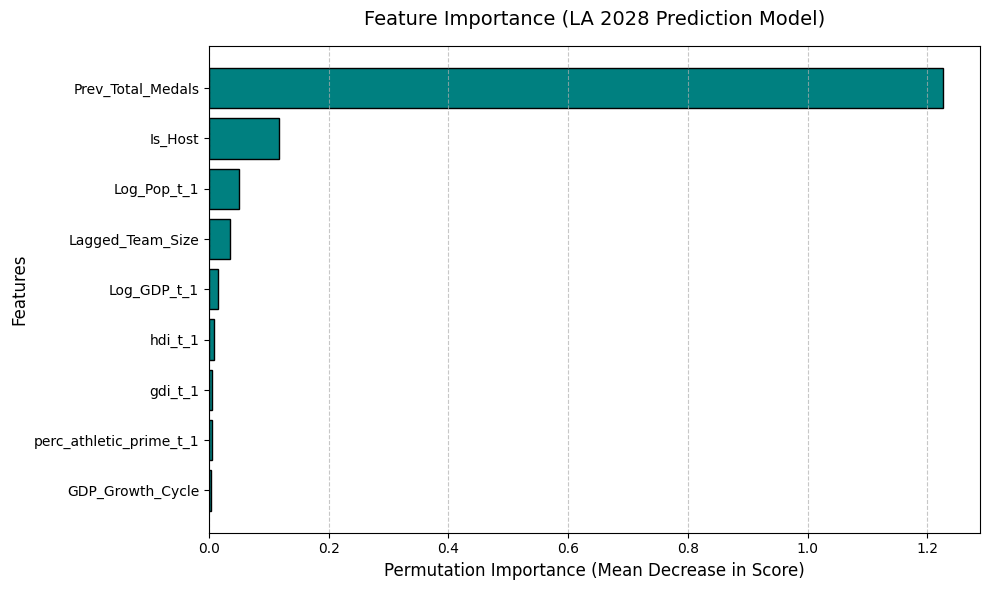

In [7]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.inspection import permutation_importance
import matplotlib.pyplot as plt





perm = permutation_importance(rf, X_train, y_train, n_repeats=10, random_state=42)
imp_df = pd.DataFrame({
     'Feature': final_features,
     'Importance_Mean': perm.importances_mean
}).sort_values('Importance_Mean', ascending=False)
print("\n--- FEATURE IMPORTANCE (COMPLETE MODEL TRAINED UP TO 2024) ---")
print(imp_df.to_string(index=False))




#  features
imp_df_sorted = imp_df.sort_values('Importance_Mean', ascending=True)

plt.figure(figsize=(10, 6))
plt.barh(imp_df_sorted['Feature'], imp_df_sorted['Importance_Mean'], color='teal', edgecolor='black')

plt.xlabel('Permutation Importance (Mean Decrease in Score)', fontsize=12)
plt.ylabel('Features', fontsize=12)
plt.title('Feature Importance (LA 2028 Prediction Model)', fontsize=14, pad=15)
plt.grid(axis='x', linestyle='--', alpha=0.7)

# Adjust layout so labels aren't truncated
plt.tight_layout()

# Display the plot
plt.show()

In [3]:
import matplotlib.pyplot as plt
import shap

# SHAP plot zoomed in 
plt.figure(figsize=(10, 8))

#  the SHAP plot 
shap.summary_plot(shap_values, X_train, show=False)

# A range of -5 to 15 is usually perfect because it shows the negative 
# clusters for small countries and lets the socio-economic swarms breathe.
plt.xlim(-5, 15) 


plt.title('SHAP Bee Swarm Plot (High-Resolution Socio-Economic Interval)', fontsize=14)
plt.xlabel('SHAP value (impact on model output - truncated scale)')
plt.tight_layout()

plt.savefig('shap_beeswarm_zoomed.png', dpi=300)
plt.close()